## Aplicação da extrategia de investimento do Barsi


### Criterios:
- Investir somente em bancos, energia, saneamento, seguros e telecomunicação
- Investir em empresas que o P/VP estejam abaixo de 1
- Ter um preço teto de compra onde retorne no mínimo 6% de yeld

Obs: O valor investido mensal será 7,5%
O preço teto definido será levado a valor anterior utilizando IPCA médio
O backtest será de 01/01/1994 até 01/01/2025

### Importar  Bibliotecas Necessarias

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import investpy as inv
from datetime import timedelta


In [38]:
# Pegar nomes das empresas que estão na bolsa no brasil
bolsa_br = inv.stocks.get_stocks(country= "Brazil")

In [39]:
ticket = bolsa_br["symbol"]
# Como será utilizado somente ações, para evitar analise de ativos diferentes,
#serão desconsiderados os com final 11, porém serem caracteristicas de fundos

In [40]:
# É necessario colocar no final de cada ação .SA, para que consigamos realizar
#o web scraping das informações do yahool
lista_acoes = [ativo+".SA" for ativo in ticket if len(ativo)== 5]
print(len(lista_acoes))

390


In [41]:
# Realizar filto baseado no setor
filtro_barsi = []
filtros =["Financial Services", "Utilities", "Telecom services"]
for acao in lista_acoes:
    empresa = yf.Ticker(acao)
    try:
        informacoes = empresa.info
        if informacoes:
            setor = informacoes.get("sector")
            if setor in filtros:
                filtro_barsi.append(acao)
    except:
        continue


404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/GFSA1.SA?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=GFSA1.SA&crumb=e.rHKyoXsik
404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/CELP6.SA?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=CELP6.SA&crumb=e.rHKyoXsik
404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/JBDU1.SA?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=JBDU1.SA&crumb=e.rHKyoXsik
404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/JBDU2.SA?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDe

In [42]:
empresa = yf.Ticker('BBAS3.SA')
informacoes = empresa.dividends
informacoes

Date
2008-05-15 00:00:00-03:00    0.112108
2009-06-23 00:00:00-03:00    0.090111
2009-08-14 00:00:00-03:00    0.095437
2009-09-22 00:00:00-03:00    0.092699
2009-11-13 00:00:00-02:00    0.061449
                               ...   
2024-06-14 00:00:00-03:00    0.204240
2024-08-22 00:00:00-03:00    0.474655
2024-09-12 00:00:00-03:00    0.186602
2024-11-26 00:00:00-03:00    0.483304
2024-12-12 00:00:00-03:00    0.176491
Name: Dividends, Length: 123, dtype: float64

In [43]:
print(len(lista_acoes), len(filtro_barsi))

390 83


In [44]:
#Crir um dataframe para facilitar analise
df_acoes = pd.DataFrame(filtro_barsi, columns= ["Ticker"])
# de 749 de ativos apos o filtro restaram 84     

In [45]:
# Criar logica para pegar os tempos que serão utilizados
ano_atual = '2024-12-31'
ano_atual = pd.to_datetime(ano_atual)
PERIODO = 5

passado = ano_atual - timedelta(days=365 * PERIODO)

#timesdelta da errado com o .year se substituir ele da certo

In [46]:
#Pegar o valor patrimonial que ordenará a escolha das
contador = 0
while contador <len(df_acoes):
    for acao in df_acoes["Ticker"]:
        empresa= yf.Ticker(acao)
        precos = empresa.history(start= passado, end= ano_atual, period = "1y")
        media_preco = precos["Close"].mean()
        informacoes = empresa.info
        valor_patrimonial = informacoes.get("bookValue")
        p_vp = media_preco/ valor_patrimonial
        df_acoes.loc[contador, "Preco_Valor_Patrimonial"] = p_vp
        df_acoes.loc[contador, "Preco_medio"] = media_preco
        contador += 1


In [47]:
# Filtrar ações que não pagarão pelo menos 4% de yeld no último ano 
contador = 0
while contador < len(df_acoes):
    for acao in df_acoes["Ticker"]:
        empresa=yf.Ticker(acao)
        dividendo = empresa.dividends
        if not dividendo.empty:
            dividendos_filtrados = dividendo.loc[dividendo.index.year>= (ano_atual.year - PERIODO)]
            dividendos_anuais_filtrado = dividendos_filtrados.groupby(dividendos_filtrados.index.year).sum()
            if dividendos_anuais_filtrado.empty:
                dividendos_media = 0 
            else:
                dividendos_media = dividendos_anuais_filtrado.mean()
        df_acoes.loc[contador, "Media_Dividendos"]= dividendos_media
        contador+=1
# Obs: Como o yfinance desconsidera jscp como pagamento de proventos, e o mesmo
# é quase 30% na remuneração total que os acionista recebem, então irei fazer
# ajuste no dy teto para compensar essa redução de proventos feito pelo sistema
# 6 % passará para 4%
        

In [48]:
contador = 0
yield_minimo = 0.06
while contador < len(df_acoes):
    for acao in df_acoes["Ticker"]:
        df_acoes.loc[contador, 'Preco_Teto'] = df_acoes.loc[contador, 'Media_Dividendos']/yield_minimo
        df_acoes.loc[contador,"Dividend_yeld_medio"]= (df_acoes.loc[contador, "Media_Dividendos"] / df_acoes.loc[contador, "Preco_medio"] *100)
        contador += 1

In [49]:
# Como a biblioteca n considera JSCP, todos os valores encontrados são apenas
# de dividendos e dividendos muito alto podem significar pagamentos não
# não recorrentes, para evitar isso será considerado empresa com no máximo 15%

df_acoes_invest = df_acoes[df_acoes["Dividend_yeld_medio"] <= 15]
df_acoes_investi =  df_acoes_invest[df_acoes_invest["Dividend_yeld_medio"]>= 6]
df_acoes_investi
df_acoes_investir =  df_acoes_investi[df_acoes_investi["Preco_Valor_Patrimonial"]< 1]
df_acoes_investir=df_acoes_investir.reset_index(drop= True)


In [50]:
len(df_acoes_investir)

30

In [51]:
# Ordenando ações baseado no nível de descontto pago pela empresa
df_acoes_investir['Empresa']= df_acoes_investir['Ticker'].str[:4]
df_acoes_investir = df_acoes_investir.sort_values(by = ["Dividend_yeld_medio"], ascending= [False])
df_acoes_investir

,Ticker,Preco_Valor_Patrimonial,Preco_medio,Media_Dividendos,Preco_Teto,Dividend_yeld_medio,Empresa
9,CSMG3.SA,0.618512,13.127922,1.516890,25.281498,11.554684,CSMG
6,CMIG4.SA,0.669453,6.406665,0.714989,11.916490,11.160088,CMIG
26,TAEE3.SA,0.472978,9.527659,1.048864,17.481064,11.008621,TAEE
29,BMGB4.SA,0.353435,2.651466,0.279293,4.654881,10.533526,BMGB
11,PINE4.SA,0.447984,2.442858,0.254050,4.234167,10.399702,PINE
25,TAEE4.SA,0.479964,9.668395,1.004506,16.741767,10.389584,TAEE
23,BMIN4.SA,0.486229,14.114741,1.431604,23.860069,10.142617,BMIN
5,CMIG3.SA,0.901777,8.630005,0.833006,13.883436,9.652441,CMIG
15,BAZA3.SA,0.422904,49.270479,4.425096,73.751606,8.981233,BAZA
4,BRSR6.SA,0.382492,9.740532,0.872936,14.548931,8.961891,BRSR


In [52]:
CARTEIRA_cemig = df_acoes_investir.drop_duplicates("Empresa", keep='first')
CARTEIRA = CARTEIRA_cemig[CARTEIRA_cemig['Ticker']!= 'CMIG4.SA'].head(10)
# Será retirada a ação merc4 devido a ter uma dupla exposição em mercantil
# e por ter tickers diferente não foi possivel remover pelo drop_duplicates
CARTEIRA_BARSI = CARTEIRA[['Ticker', 'Preco_Teto']].reset_index(drop=True)
CARTEIRA_BARSI

,Ticker,Preco_Teto
0,CSMG3.SA,25.281498
1,TAEE3.SA,17.481064
2,BMGB4.SA,4.654881
3,PINE4.SA,4.234167
4,BMIN4.SA,23.860069
5,BAZA3.SA,73.751606
6,BRSR6.SA,14.548931
7,BBAS3.SA,24.496683
8,ABCB4.SA,20.881658
9,CLSC4.SA,65.709417


# Inflação média
De acordo com a calculadora de calculo de IPCA DO IBGE, 100 reais em janeiro de 2000 até dezembro de 2024 seria o mesmo que 447,39 de hoje, totalizando um tempo de 25 anos, logo usando o método 
CAGR(Crescimento composto) = (VALOR_FINAL/ VALOR_INICIAL) ^(1/ TEMPO), podemos definir a inflação média anual baseado nesse retorno que em valores é
CAGR = (447,39/100)^(1/25) - > 6,18/%
Artigo falando sobre = https://www.suno.com.br/artigos/cagr/
Terminal = ctrl + '
Será considerado o salario mínimo do ano, o primeiro ecreto do ano em questão, ex caso houve um decreto em maio e em setembro, oq será considerado é o de maio


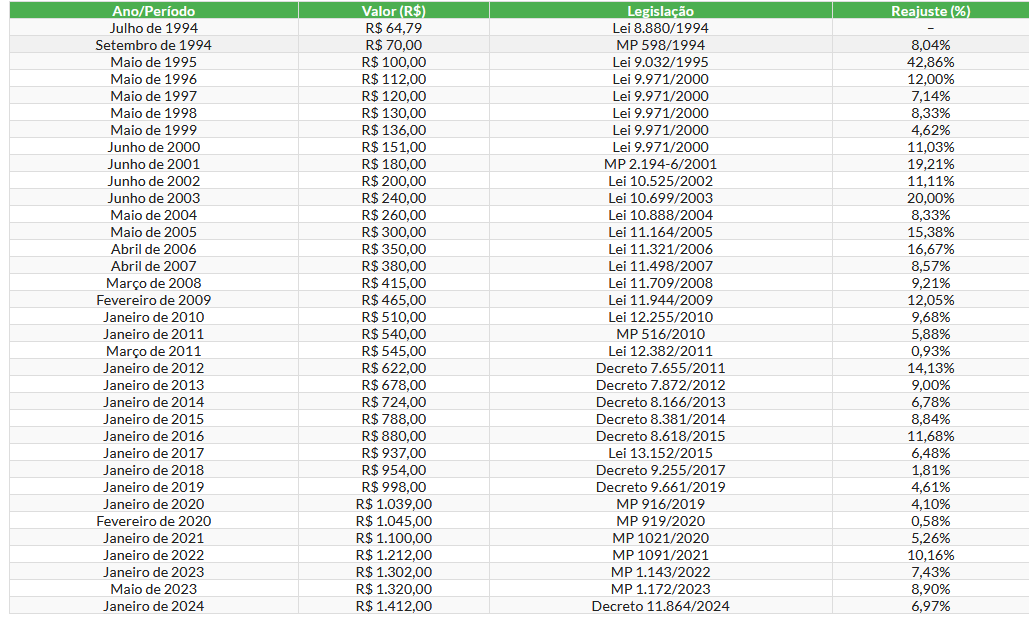

https://www.mixvale.com.br/tabela-historica-dos-salarios-minimos-de-1994-a-2024/?gad_source=1&gclid=Cj0KCQiA3sq6BhD2ARIsAJ8MRwXtONZhQOMwk2TAOrHz5_f1Mg_BC0WSo_U1ozMQYd20W21Ypjh_w3oaAgGsEALw_wcB


In [53]:
# Para definir o valor do salario a ser utilizado será utilizado uma função que irá retornar o valor em questão
def investimento_ano(ano):
    SALARIOS = {2000:151,2001:180,2002:200, 2003:240, 2004:260, 2005:300,2006:350,2007:380,2008:415,2009:465,2010:510,2011:540,2012:622,2013:678,
            2014:724,2015:788,2016:880,2017:937,2018:954,2019:998,2020:1039,2021:1100,2022:1212,2023:1302,2024:1412}
    TAXA_INVEST = 0.075
    ano_atual = {}
    for anos in SALARIOS.keys():
        if anos == ano:
            ano_atual[ano]= SALARIOS[ano]
            valor_investido = ano_atual[ano]*TAXA_INVEST
    return round(valor_investido,2)

In [54]:
def correcao(ano,preco):
    INFLACAO_MEDIA = 0.0618
    ano_atual=pd.Timestamp.now().year
    periodo_correcao = ano_atual- ano
    correcao = (1+INFLACAO_MEDIA)**periodo_correcao
    preco_teto_corrigido = round((preco/correcao),2)
    return round(preco_teto_corrigido,2)

In [55]:
# Tempo do backtest
ano_inicio = '2000-01-01'
ano_inicio = pd.to_datetime(ano_inicio)
ano_atual='2024-12-31'
ano_atual=pd.to_datetime(ano_atual)

In [56]:

preco_ativos = {}
for ativos in CARTEIRA_BARSI['Ticker']:
    empresa = yf.Ticker(ativos)
    dados = empresa.history(start=ano_inicio, end=ano_atual, period='1mo')
    preco = dados['Close']
    preco_ativos[ativos] = preco.resample('M').last()
precos = pd.DataFrame(preco_ativos)


C:\Users\edens\AppData\Local\Temp\ipykernel_26508\585858155.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco_ativos[ativos] = preco.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_26508\585858155.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco_ativos[ativos] = preco.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_26508\585858155.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco_ativos[ativos] = preco.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_26508\585858155.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco_ativos[ativos] = preco.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_26508\585858155.py:6: FutureWarning: 'M' is deprecated and will be removed in a future v

In [57]:
# Transformando o índice (datas) em uma coluna
bolsa_barsi=precos.reset_index()
bolsa_barsi

,Date,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
0,2000-01-31 00:00:00-02:00,NaN,NaN,NaN,NaN,NaN,15.541043,NaN,0.465056,NaN,NaN
1,2000-02-29 00:00:00-03:00,NaN,NaN,NaN,NaN,NaN,13.490949,NaN,0.438566,NaN,NaN
2,2000-03-31 00:00:00-03:00,NaN,NaN,NaN,NaN,NaN,13.623214,NaN,0.370279,NaN,NaN
3,2000-04-30 00:00:00-03:00,NaN,NaN,NaN,NaN,NaN,13.226420,NaN,0.353207,NaN,NaN
4,2000-05-31 00:00:00-03:00,NaN,NaN,NaN,NaN,NaN,12.234439,NaN,0.329660,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31 00:00:00-03:00,22.477026,11.544510,3.514680,4.456480,16.00,98.500000,11.676416,27.222099,22.286385,73.612267
296,2024-09-30 00:00:00-03:00,22.134035,11.181598,3.514680,4.383123,16.50,91.099998,10.862386,26.484249,20.886896,79.634514
297,2024-10-31 00:00:00-03:00,22.143641,11.367958,3.802602,4.418293,16.40,91.330002,10.561957,25.656006,20.052954,74.145416
298,2024-11-30 00:00:00-03:00,24.382023,11.320000,3.830980,4.360662,16.15,84.699997,10.214587,24.597614,19.391552,78.591690


In [58]:
SALARIOS = {2000:151,2001:180,2002:200, 2003:240, 2004:260, 2005:300,2006:350,2007:380,2008:415,2009:465,2010:510,2011:540,2012:622,2013:678,
            2014:724,2015:788,2016:880,2017:937,2018:954,2019:998,2020:1039,2021:1100,2022:1212,2023:1302,2024:1412}

In [59]:
for ano in SALARIOS.keys():
    contador = 0
    while contador < len(CARTEIRA_BARSI):
        preco_teto = CARTEIRA_BARSI.loc[contador, 'Preco_Teto']
        CARTEIRA_BARSI.loc[contador,ano] = correcao(ano,preco_teto)
        contador+=1

CARTEIRA_BARSI

,Ticker,Preco_Teto,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CSMG3.SA,25.281498,5.65,5.99,6.37,6.76,7.18,7.62,8.09,8.59,...,13.88,14.74,15.65,16.62,17.64,18.73,19.89,21.12,22.42,23.81
1,TAEE3.SA,17.481064,3.90,4.15,4.40,4.67,4.96,5.27,5.59,5.94,...,9.60,10.19,10.82,11.49,12.20,12.95,13.75,14.60,15.51,16.46
2,BMGB4.SA,4.654881,1.04,1.10,1.17,1.24,1.32,1.40,1.49,1.58,...,2.56,2.71,2.88,3.06,3.25,3.45,3.66,3.89,4.13,4.38
3,PINE4.SA,4.234167,0.95,1.00,1.07,1.13,1.20,1.28,1.36,1.44,...,2.32,2.47,2.62,2.78,2.95,3.14,3.33,3.54,3.76,3.99
4,BMIN4.SA,23.860069,5.33,5.66,6.01,6.38,6.77,7.19,7.64,8.11,...,13.10,13.91,14.77,15.68,16.65,17.68,18.77,19.93,21.16,22.47
5,BAZA3.SA,73.751606,16.47,17.49,18.57,19.72,20.94,22.23,23.60,25.06,...,40.49,42.99,45.65,48.47,51.47,54.65,58.02,61.61,65.42,69.46
6,BRSR6.SA,14.548931,3.25,3.45,3.66,3.89,4.13,4.39,4.66,4.94,...,7.99,8.48,9.01,9.56,10.15,10.78,11.45,12.15,12.90,13.70
7,BBAS3.SA,24.496683,5.47,5.81,6.17,6.55,6.95,7.38,7.84,8.32,...,13.45,14.28,15.16,16.10,17.09,18.15,19.27,20.46,21.73,23.07
8,ABCB4.SA,20.881658,4.66,4.95,5.26,5.58,5.93,6.29,6.68,7.10,...,11.46,12.17,12.92,13.72,14.57,15.47,16.43,17.44,18.52,19.67
9,CLSC4.SA,65.709417,14.67,15.58,16.54,17.57,18.65,19.80,21.03,22.33,...,36.07,38.30,40.67,43.18,45.85,48.69,51.70,54.89,58.28,61.88


In [60]:
# Substituir NaN por 0 em todo o DataFrame
bolsa_barsi.fillna(0.00, inplace=True)
bolsa_barsi

,Date,CSMG3.SA,TAEE3.SA,BMGB4.SA,PINE4.SA,BMIN4.SA,BAZA3.SA,BRSR6.SA,BBAS3.SA,ABCB4.SA,CLSC4.SA
0,2000-01-31 00:00:00-02:00,0.000000,0.000000,0.000000,0.000000,0.00,15.541043,0.000000,0.465056,0.000000,0.000000
1,2000-02-29 00:00:00-03:00,0.000000,0.000000,0.000000,0.000000,0.00,13.490949,0.000000,0.438566,0.000000,0.000000
2,2000-03-31 00:00:00-03:00,0.000000,0.000000,0.000000,0.000000,0.00,13.623214,0.000000,0.370279,0.000000,0.000000
3,2000-04-30 00:00:00-03:00,0.000000,0.000000,0.000000,0.000000,0.00,13.226420,0.000000,0.353207,0.000000,0.000000
4,2000-05-31 00:00:00-03:00,0.000000,0.000000,0.000000,0.000000,0.00,12.234439,0.000000,0.329660,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31 00:00:00-03:00,22.477026,11.544510,3.514680,4.456480,16.00,98.500000,11.676416,27.222099,22.286385,73.612267
296,2024-09-30 00:00:00-03:00,22.134035,11.181598,3.514680,4.383123,16.50,91.099998,10.862386,26.484249,20.886896,79.634514
297,2024-10-31 00:00:00-03:00,22.143641,11.367958,3.802602,4.418293,16.40,91.330002,10.561957,25.656006,20.052954,74.145416
298,2024-11-30 00:00:00-03:00,24.382023,11.320000,3.830980,4.360662,16.15,84.699997,10.214587,24.597614,19.391552,78.591690


In [61]:
# Comprar acoes
#mesmo contando o df no preco teto ele ainda retorna um dataframe, para ter o valor realmente precisa coverte-lo, pois ele retorna uma matriz panda series, por isso o .values[0]
contador = 0
saldo=0
carteira_contabil_barsi = 0
valor_investido_barsi = 0
compras_barsi ={acao:0 for acao in CARTEIRA_BARSI['Ticker']}
while contador < len(bolsa_barsi):
    data = bolsa_barsi.loc[contador,"Date"].year
    saldo+=investimento_ano(data)
    valor_investido_barsi+=investimento_ano(data)
    while True:
        compra_acao = False
        for acao in CARTEIRA_BARSI['Ticker']:
            preco= bolsa_barsi.loc[contador,acao]
            Preco_teto = CARTEIRA_BARSI.loc[CARTEIRA_BARSI['Ticker']==acao,data].values[0]
            if preco >0 and preco< Preco_teto and saldo> preco:
                compras_barsi[acao]+=1
                saldo-=preco
                carteira_contabil_barsi += preco
                compra_acao=True
        if not compra_acao:
            break
    contador+=1
print(compras_barsi)
print(carteira_contabil_barsi)
print(valor_investido_barsi)
#Pq precisa do break para dar restart no while

{'CSMG3.SA': 367, 'TAEE3.SA': 305, 'BMGB4.SA': 119, 'PINE4.SA': 126, 'BMIN4.SA': 133, 'BAZA3.SA': 307, 'BRSR6.SA': 158, 'BBAS3.SA': 728, 'ABCB4.SA': 147, 'CLSC4.SA': 41}
14969.80431136489
14973.120000000006


In [62]:
file = pd.ExcelWriter('Arquivo_Barsi.xlsx', engine='openpyxl')
bolsa_barsi_salv= bolsa_barsi.fillna(0)
bolsa_barsi_salv['Date'] = bolsa_barsi['Date'].dt.strftime('%Y-%m-%d')
bolsa_barsi_salv.to_excel(file, sheet_name='Bolsa Barsi', index=False)
dicionario_inf = {
    'Nome':['carteira_contabil_barsi','valor_investido_barsi'],
    'Valor':[carteira_contabil_barsi,valor_investido_barsi]}
df_valor = pd.DataFrame(dicionario_inf)
df_valor.to_excel(file, sheet_name='valor_investido_vs_investimento', index=False)
compra_feita = {
    'Acao' : [acao for acao in compras_barsi.keys()],
    'Qtd_comprada': [valor for valor in compras_barsi.values()]}
compra_df = pd.DataFrame(compra_feita)
compra_df.to_excel(file, sheet_name='Compras', index=False)
file.close()